# World Happiness Report — Visualisations
Requires `happiness_clean.csv` produced by `main_analysis.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
df = pd.read_csv('happiness_clean.csv')
print(df.shape)
df.head(3)

(2116, 16)


,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual,tier,has_breakdown,score_change_yoy
0,2011,131,Afghanistan,4.258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bottom,False,NaN
1,2012,143,Afghanistan,4.040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bottom,False,-0.218
2,2014,153,Afghanistan,3.575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bottom,False,-0.465


## 1  Global score distribution by year

C:\Users\Matvey\AppData\Local\Temp\ipykernel_20584\715547655.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_year, labels=years, patch_artist=True, notch=False)


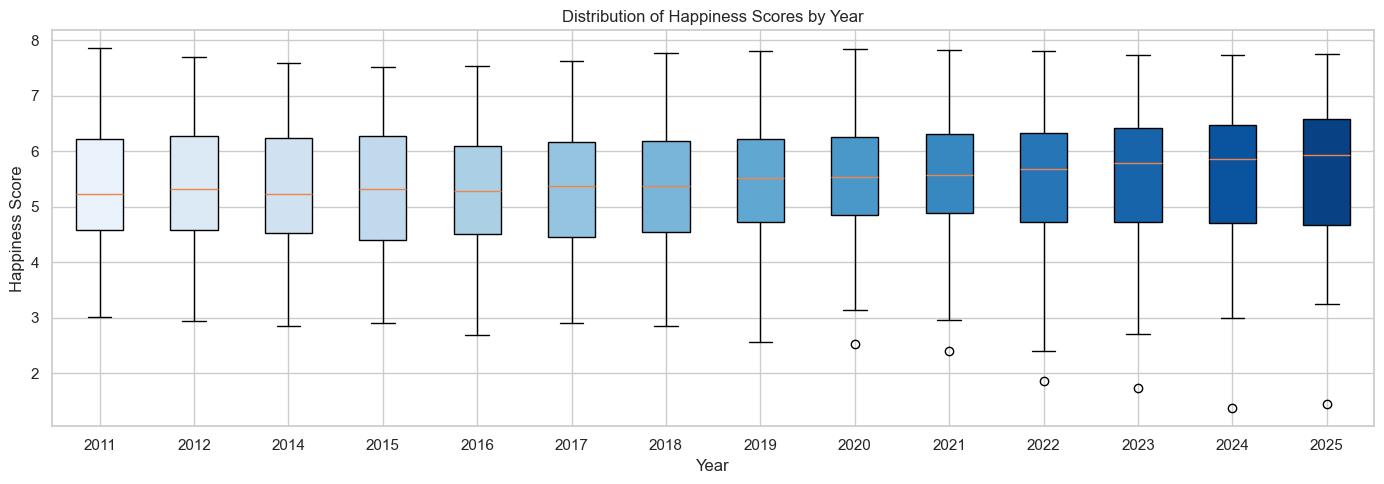

In [2]:
fig, ax = plt.subplots(figsize=(14, 5))
years = sorted(df['year'].unique())
data_by_year = [df.loc[df['year'] == y, 'happiness_score'].values for y in years]
bp = ax.boxplot(data_by_year, labels=years, patch_artist=True, notch=False)
colors = sns.color_palette('Blues', len(years))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_title('Distribution of Happiness Scores by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Happiness Score')
plt.tight_layout()
plt.savefig('plot_score_distribution.png', dpi=150)
plt.show()

## 2  Top 10 countries in 2025

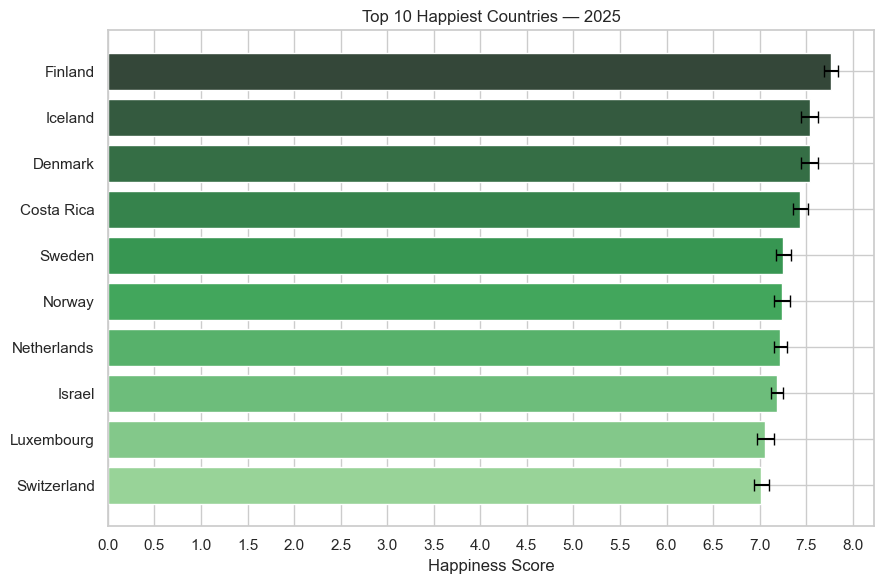

In [3]:
top10 = df[df['year'] == 2025].nsmallest(10, 'rank_in_year').sort_values('happiness_score')
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top10['country'], top10['happiness_score'], color=sns.color_palette('Greens_d', 10))
if top10['lower_whisker'].notna().all():
    xerr = [top10['happiness_score'] - top10['lower_whisker'],
            top10['upper_whisker'] - top10['happiness_score']]
    ax.errorbar(top10['happiness_score'], top10['country'], xerr=xerr,
                fmt='none', color='black', capsize=4)
ax.set_title('Top 10 Happiest Countries — 2025')
ax.set_xlabel('Happiness Score')
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.5))
plt.tight_layout()
plt.savefig('plot_top10_2025.png', dpi=150)
plt.show()

## 3  Trend lines for selected countries

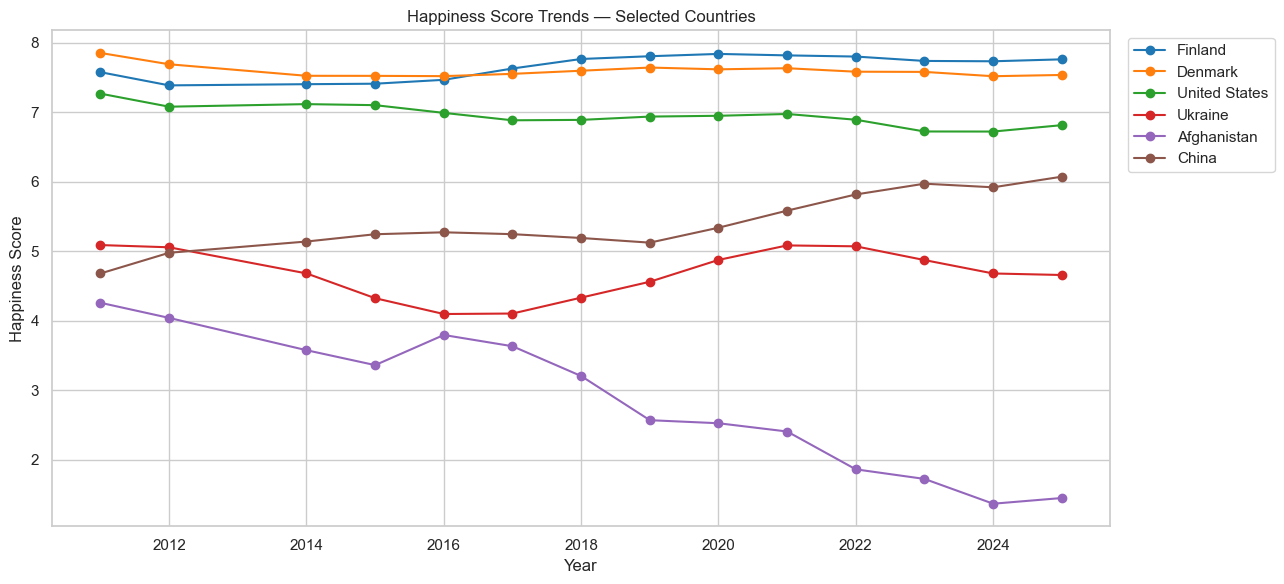

In [4]:
COUNTRIES = ['Finland', 'Denmark', 'United States', 'Ukraine', 'Afghanistan', 'China']
fig, ax = plt.subplots(figsize=(13, 6))
palette = sns.color_palette('tab10', len(COUNTRIES))
for country, color in zip(COUNTRIES, palette):
    sub = df[df['country'] == country].sort_values('year')
    ax.plot(sub['year'], sub['happiness_score'], marker='o', label=country, color=color)
ax.set_title('Happiness Score Trends — Selected Countries')
ax.set_xlabel('Year')
ax.set_ylabel('Happiness Score')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot_trends.png', dpi=150)
plt.show()

## 4  Stacked bar — factor breakdown for top 15 (2025)

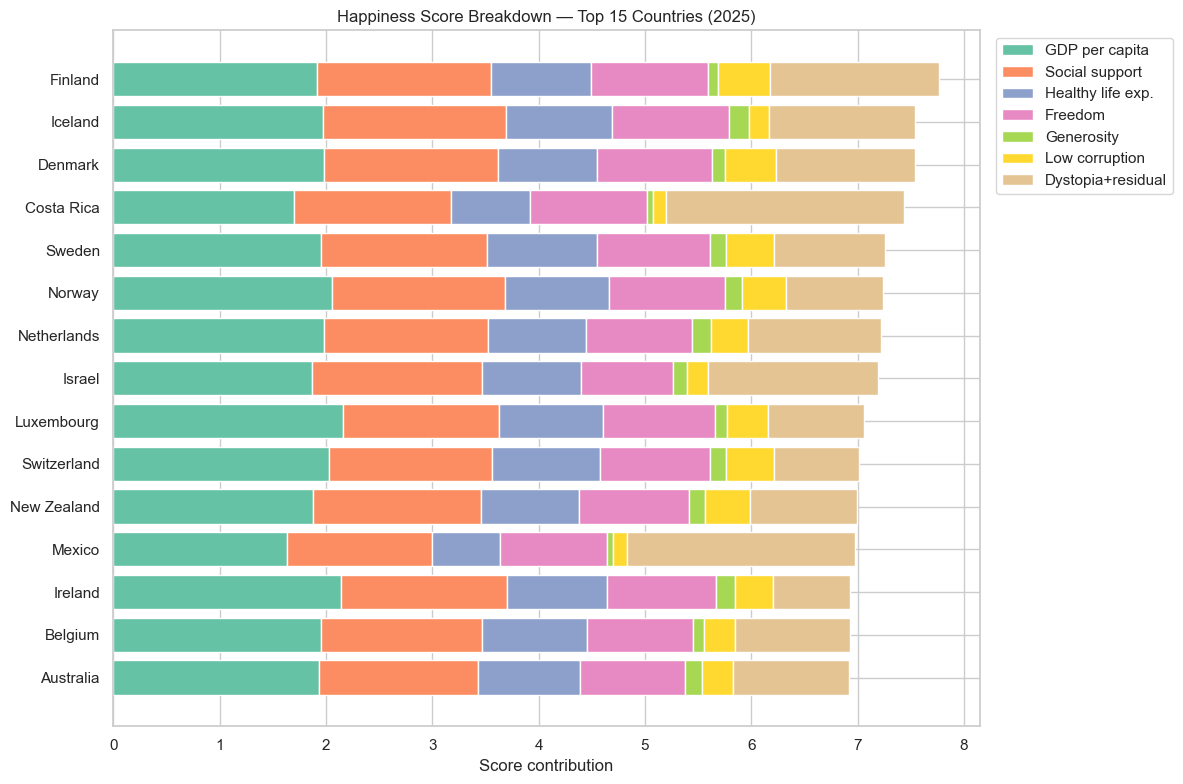

In [5]:
breakdown_cols = [
    'explained_log_gdp_per_capita', 'explained_social_support',
    'explained_healthy_life_expectancy', 'explained_freedom',
    'explained_generosity', 'explained_corruption', 'dystopia_plus_residual'
]
nice_labels = ['GDP per capita', 'Social support', 'Healthy life exp.',
               'Freedom', 'Generosity', 'Low corruption', 'Dystopia+residual']

top15 = (df[(df['year'] == 2025) & df['has_breakdown']]
         .nsmallest(15, 'rank_in_year')
         .sort_values('happiness_score', ascending=True))

fig, ax = plt.subplots(figsize=(12, 8))
palette = sns.color_palette('Set2', len(breakdown_cols))
left = np.zeros(len(top15))
for col, label, color in zip(breakdown_cols, nice_labels, palette):
    ax.barh(top15['country'], top15[col], left=left, label=label, color=color)
    left += top15[col].values
ax.set_title('Happiness Score Breakdown — Top 15 Countries (2025)')
ax.set_xlabel('Score contribution')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot_breakdown_top15.png', dpi=150)
plt.show()

## 5  Correlation heatmap (2025 breakdown columns)

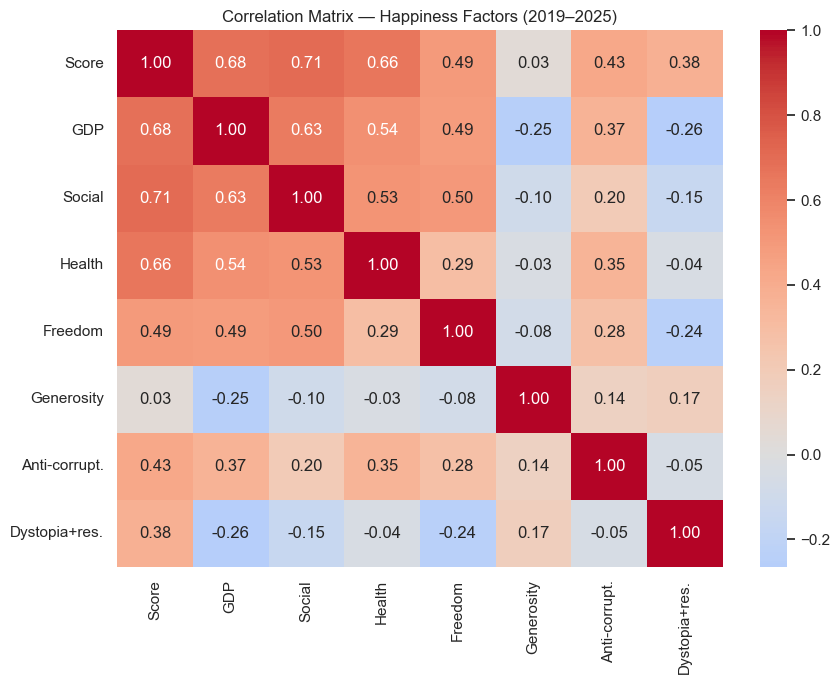

In [6]:
corr_df = df[df['has_breakdown']][['happiness_score'] + breakdown_cols].copy()
corr_df.columns = ['Score', 'GDP', 'Social', 'Health', 'Freedom', 'Generosity', 'Anti-corrupt.', 'Dystopia+res.']
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix — Happiness Factors (2019–2025)')
plt.tight_layout()
plt.savefig('plot_correlation.png', dpi=150)
plt.show()

## 6  Rank change heatmap (2011 → 2025)

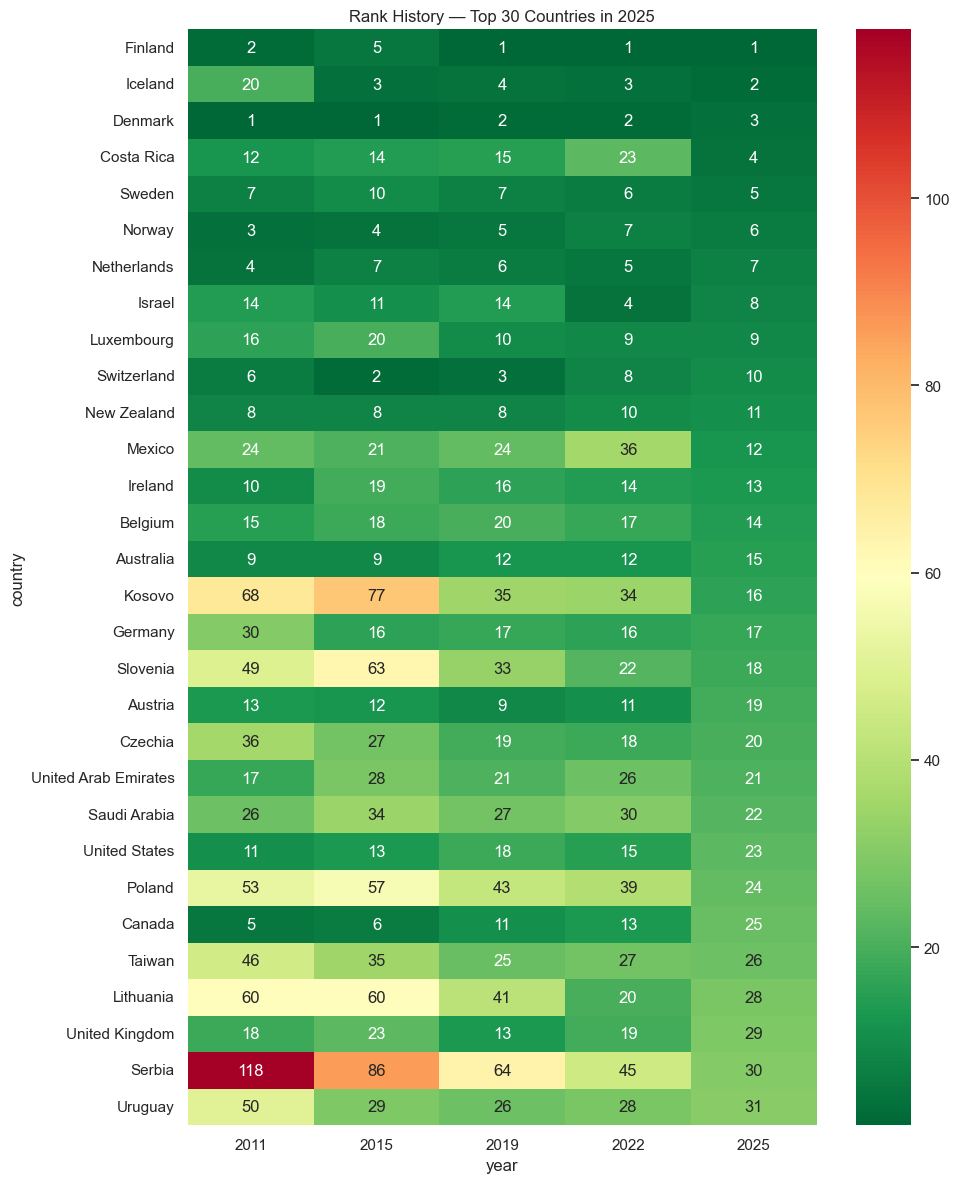

In [7]:
pivot = df[df['year'].isin([2011, 2015, 2019, 2022, 2025])].pivot_table(
    index='country', columns='year', values='rank_in_year'
)
# Only countries present in all 5 selected years
pivot = pivot.dropna()
# Sort by 2025 rank
pivot = pivot.sort_values(2025)
top30 = pivot.head(30)

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(top30, annot=True, fmt='.0f', cmap='RdYlGn_r', ax=ax)
ax.set_title('Rank History — Top 30 Countries in 2025')
plt.tight_layout()
plt.savefig('plot_rank_heatmap.png', dpi=150)
plt.show()